# A_bg の行をそのまま C に入れると、どうなる？

このノートは、有用性の観点 $U_\text{valid}$（妥当性）の中にある**行の新規性（novel）**を扱います（ルールブック §6.1.4）。

**ここで採点する観点**

- $C$ が、全チームに公開されている背景データ $A_\text{bg}$ にはない、$B$ についての新しい情報を含んでいるか。$A_\text{bg}$ と $B$ は重なりのない別の個人の集まりなので、$C$ が $A_\text{bg}$ の行を選び直しただけのものだと、分析者の手元に新しい個人の観測は1件も増えません。$A_\text{bg}$ で学習したモデルの性能をその $C$ で確かめる、といった使い方もできなくなります（学習に使ったのと同じ個人で測ることになるためです）。

所要 10 分。

## 0. 準備

練習データ（`participant_data/B_practice.csv`）を使います。

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

# 配布データの場所を探す（リポジトリの配置でも、zip を展開しただけの配置でも動くように）
DATA = next(p for p in (Path('..'), Path('../participant_data'), Path('participant_data'))
            if (p / 'B_practice.csv').exists())

from pwscup2026.kit import selfscore as ss        # CodaBench と同じ採点器

B_ref, REF, CFG, info = ss.load_local_reference(DATA)   # 採点器が使う参照値とパラメータ

# 採点と同じ読み方で読む（float_precision='round_trip'）。既定の読み方だと小数の末尾の桁がずれ、
# 値を変えていない列でも点数がごくわずかに下がることがあります。
B = pd.read_csv(DATA / 'B_practice.csv', float_precision='round_trip')

def score(C: pd.DataFrame) -> dict:
    # C を採点して {utility, facets, detail} を返す（CodaBench と同じ採点器）
    return ss.self_score(C.copy(), B_ref, REF, CFG)

print(f'B: {B.shape[0]} 行 × {B.shape[1]} 列')

B: 1049 行 × 14 列


In [2]:
A_bg = pd.read_csv(DATA / 'A_bg.csv', float_precision='round_trip')
print(f'A_bg: {A_bg.shape[0]} 行 × {A_bg.shape[1]} 列')

A_bg: 5143 行 × 14 列


## 1. 測り方

1. prefecture を除く12列を、$A_\text{bg}$ の平均と標準偏差で標準化します（各列から $A_\text{bg}$ での平均を引き、標準偏差（ばらつき）で割って、列ごとの単位の違いをそろえます）。
2. $C$ の各行から、いちばん近い $A_\text{bg}$ の行までの距離（最近傍距離）を求め、距離が $t$ 以下の行の割合を $F_C(t)$ とします（累積分布）。同じことを $B$ の各行でも行い、$F_B(t)$ とします。
3. $C$ の距離が $B$ より近い側へはみ出した最大量 $D^{+}=\sup_t\,[F_C(t)-F_B(t)]$（$t$ をいろいろ動かしたときの、$F_C(t)-F_B(t)$ の最大値）を求めます。2つの累積分布の差の最大値を見る KS（コルモゴロフ–スミルノフ）統計量のうち、片側の向きだけを見るものです。
4. $\text{novel}=1-\operatorname{clip}\bigl((D^{+}-d_0)/(1-d_0),\,0,\,1\bigr)$（$\operatorname{clip}(x,0,1)$ は、$x$ が 0 未満なら 0、1 を超えたら 1 にする操作）。$d_0=0.0534$ までのはみ出しは減点しません（§2 で説明します）。

ルールブックの式どおりに計算して、採点器の値と一致することを確かめます。

In [3]:
from sklearn.neighbors import NearestNeighbors

NOVEL_COLS = ['age', 'BMI', 'SBP', 'TG', 'HDL', 'ALT', 'FPG', 'time', 'sex', 'smoking', 'onset', 'death']
mu = A_bg[NOVEL_COLS].to_numpy(dtype=float).mean(axis=0)
sd = A_bg[NOVEL_COLS].to_numpy(dtype=float).std(axis=0)
nn = NearestNeighbors(n_neighbors=1).fit((A_bg[NOVEL_COLS].to_numpy(dtype=float) - mu) / sd)

def nn_dist(df):
    # 各行から A_bg の最近傍までの距離
    return nn.kneighbors((df[NOVEL_COLS].to_numpy(dtype=float) - mu) / sd)[0].ravel()

d_B = nn_dist(B)

def novel_by_formula(C, d0=0.0534):
    # ルールブック §6.1.4 の行の新規性を式どおりに計算する
    d_C = nn_dist(C)
    t = np.sort(np.concatenate([d_C, d_B]))
    F_C = np.searchsorted(np.sort(d_C), t, side='right') / len(d_C)
    F_B = np.searchsorted(np.sort(d_B), t, side='right') / len(d_B)
    d_plus = float(max(0.0, (F_C - F_B).max()))
    return {'C の距離の中央値': float(np.median(d_C)), 'B の距離の中央値': float(np.median(d_B)),
            'D+': d_plus, 'novel': float(1 - np.clip((d_plus - d0) / (1 - d0), 0, 1))}

print('式どおりに計算:', {k: round(v, 4) for k, v in novel_by_formula(B).items()})
print('採点器の値    :', score(B)['detail']['U_valid']['novel'])

式どおりに計算: {'C の距離の中央値': 0.8066, 'B の距離の中央値': 0.8066, 'D+': 0.0, 'novel': 1.0}


採点器の値    : 1.0


## 2. 意味

- $A_\text{bg}$ と $B$ は重なりのない別の個人の集まりなので、$B$ の各行から $A_\text{bg}$ までの最近傍距離には、ある程度の大きさがあります。
- $A_\text{bg}$ の行をそのまま入れると、その行の距離は 0 になり、$C$ の距離の分布が $B$ より近い側へはみ出します。$D^{+}$ は、そのはみ出しの最大量です。
- $B$ と同じ人数の標本どうしを比べると、偶然でもある程度のはみ出しは出ます。$d_0$（同じ分布から 1,049 行ずつ引いた標本どうしを比べたとき、偶然の $D^{+}$ がこの値を超えるのが 5% になる値）まではその分とみなし、減点しません。
- 見ているのは「近い側へのはみ出し」だけです。$C$ の行が $A_\text{bg}$ から $B$ より遠くても、減点されません。
- $U_\text{valid}$ は4つの指標（打ち切り整合・関係の非捏造〔県・性別・喫煙による差を本物より強めていないか〕・重複行・行の新規性）の**平均**なので、novel だけで $U_\text{valid}$ が下がる幅は最大 0.25 です。

## 3. 壊してみる

### 3.1 行を A_bg の行に置き換える

$B$ の 10%・25%・50%・100% の行を、$A_\text{bg}$ から無作為に選んだ行に置き換えます。

In [4]:
def replace_with_abg(df, p, seed=0):
    rng = np.random.default_rng(seed)
    out = df.copy()
    n = len(out); k = int(round(p * n))
    cols = [c for c in out.columns if c != 'record_id']
    if k:
        dst = rng.choice(n, k, replace=False)
        out.loc[out.index[dst], cols] = A_bg.sample(n=k, random_state=seed)[cols].to_numpy()
    return out

REPL = {f'{int(p * 100)}% を A_bg の行に': replace_with_abg(B, p) for p in (0.10, 0.25, 0.50, 1.00)}
rows = {}
for name, C in {'加工なし': B, **REPL}.items():
    o = score(C)
    rows[name] = {**novel_by_formula(C), '採点器の novel': o['detail']['U_valid']['novel'],
                  'U_valid': o['facets']['U_valid']}
pd.DataFrame(rows).T.round(4)

,C の距離の中央値,B の距離の中央値,D+,novel,採点器の novel,U_valid
加工なし,0.8066,0.8066,0.0000,1.0000,1.0000,1.0000
10% を A_bg の行に,0.7570,0.8066,0.1001,0.9507,0.9507,0.9872
25% を A_bg の行に,0.6650,0.8066,0.2498,0.7926,0.7926,0.9472
50% を A_bg の行に,0.2018,0.8066,0.4995,0.5287,0.5287,0.8815
100% を A_bg の行に,0.0000,0.8066,1.0000,0.0000,0.0000,0.7486


### 結果の解釈

- 置き換えた行は $A_\text{bg}$ の行そのものなので、距離が 0 になります。そのぶん $F_C$ が距離 0 の時点から持ち上がるので、置き換えた割合が大きいほど $D^{+}$ も大きくなります。
- novel は 10% で 0.95、25% で 0.79、50% で 0.53、100% で 0 です。

### 3.2 距離の分布を見る

25% を置き換えた $C$ について、最近傍距離の累積分布を $B$ と重ねます。縦の差がいちばん大きいところが $D^{+}$ です。

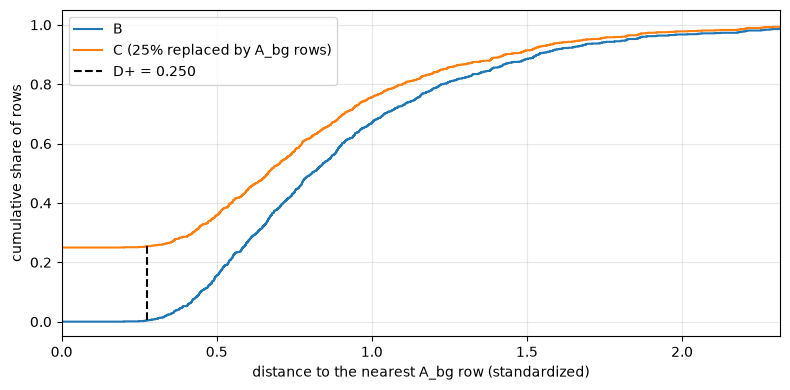

In [5]:
import matplotlib.pyplot as plt

d_C = nn_dist(REPL['25% を A_bg の行に'])
t = np.sort(np.concatenate([d_C, d_B]))
F_C = np.searchsorted(np.sort(d_C), t, side='right') / len(d_C)
F_B = np.searchsorted(np.sort(d_B), t, side='right') / len(d_B)
gap = F_C - F_B
i = int(np.flatnonzero(np.isclose(gap, gap.max())).max())   # 差が最大になる区間の右端

fig, ax = plt.subplots(figsize=(8, 4))
ax.step(t, F_B, where='post', label='B')
ax.step(t, F_C, where='post', label='C (25% replaced by A_bg rows)')
ax.vlines(t[i], F_B[i], F_C[i], colors='k', linestyles='--', label=f'D+ = {F_C[i] - F_B[i]:.3f}')
ax.set_xlabel('distance to the nearest A_bg row (standardized)'); ax.set_ylabel('cumulative share of rows')
ax.set_xlim(0, np.percentile(t, 99)); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

$C$ の曲線は、置き換えた行の距離が 0 なので、距離 0 の時点ですでに持ち上がっています。$B$ の曲線が上がり始めるまでその差が続き、この差の最大値が $D^{+}$ です（破線）。

### 3.3 B から作った合成データ

キットの参照防御（`starter/reference/` にある加工の実装例）の合成器で、$B$ だけから作った合成データを採点します。この合成器は、$B$ から列ごとの値の分布と列どうしの関係を学んで、同じ人数の架空の人を作り直します。$A_\text{bg}$ の行を選び直したものではないので、この例では novel は下がりません。

In [6]:
import sys
sys.path.insert(0, str(Path('../starter/reference').resolve()))
from pwscup2026.defense.synth import copula_survival
import _common

C_syn = copula_survival(B, _common.load_cfg(), np.random.default_rng(3))
{k: round(v, 4) for k, v in novel_by_formula(C_syn).items()}

{'C の距離の中央値': 1.0849, 'B の距離の中央値': 0.8066, 'D+': 0.001, 'novel': 1.0}

合成データの距離の中央値（1.08）は $B$（0.81）より大きく、近い側へのはみ出しはほぼありません（$D^{+}$ = 0.001）。novel は 1 です。有用性 $U$ 全体の点は、ほかの観点で決まります。

## 4. 自分の C で確かめる

行の新規性は、採点結果の `detail` → `U_valid` → `novel` です。`detail` → `U_valid` → `novel_detail` に、$D^{+}$（`d_plus`）、減点しない幅 $d_0$（`deadzone`）、$C$ と $B$ の距離の中央値（`nn_dist_C_median`・`nn_dist_B_median`）が入っています。

In [7]:
nd = score(REPL['25% を A_bg の行に'])['detail']['U_valid']['novel_detail']
{k: (round(v, 4) if isinstance(v, float) else v) for k, v in nd.items() if k != 'features'}

{'enabled': True,
 'novel': 0.7926,
 'd_plus': 0.2498,
 'deadzone': 0.0534,
 'n_rows_C': 1049,
 'n_rows_B': 1049,
 'nn_dist_C_median': 0.665,
 'nn_dist_B_median': 0.8066,
 'n_rows_A_bg': 5143}

自分の `C.csv` を、`starter/` と `participant_data/` が並んでいるフォルダに置き、そのフォルダで次のコマンドを実行すると、自己採点の `--json` の出力で同じ値を見られます。

```sh
cd starter
uv run python -m pwscup2026.kit.selfscore ../C.csv --dist ../participant_data --json
```

Docker を使う場合:

```sh
docker run --rm -v "$PWD":/w hajimeono/pwscup2026-kit:main-process-20260912 score /w/C.csv --dist /w/participant_data --json
```